# Chapter 1. 나의 첫 머신러닝

---

## 01-3 마켓과 머신러닝
---

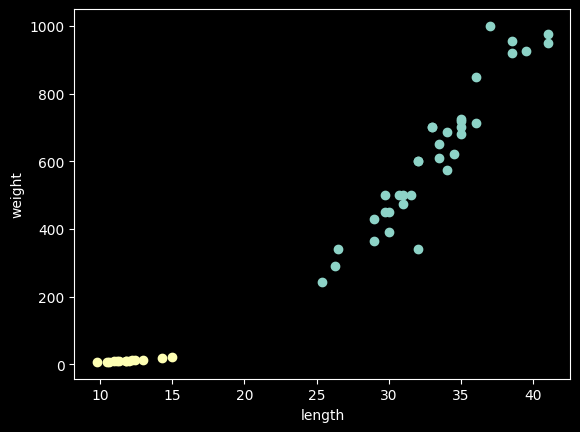

In [5]:

"""
35마리의 도미를 준비했다. 각 도미의 길이(cm)와 무게(g)를 리스트로 만들면 다음과 같다.

첫 번재 도미의 길이는 25.4cm, 무게는 242.0g이다. 각 도미의 특징을 길이와 무게로 표현한 것, 이런 것을 우리는 "특성(feature)"이라고 한다.
"""

bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]

bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

# 다음은 빙어 14마리에 대한 데이터이다.
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

# 해당 도미 데이터들을 그래프에 점으로 표시해 보려고 한다. => 산점도(scatter plot)
import matplotlib.pyplot as plt

plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)

plt.xlabel("length") # x축은 길이
plt.ylabel("weight") # y축은 무게

plt.show() # 그래프 출력

- 다음의 그래프에서 도미에 대한 부분처럼 산점도 그래프가 일직선에 가까운 형태로 나타나느 경우를 선형(linear)적이라고 말한다.

---

### 첫 번째 머신러닝
k-최근접 이웃 알고리즘을 사용해 도미와 빙어 데이터를 구분한다.


In [6]:
# 도미와 빙어 데이터를 하나로 만들어준다.
length = bream_length + smelt_length
weight = bream_weight + smelt_weight

# 여기서 사용할 머신러닝 패키지는 사이킷런(scikit-learn)이다.
# 이를 사용하기 위해서는 각 특성의 리스트를 세로 방향으로 늘여뜨려야 한다.
# => zip() 함수와 리스트 컴프리헨션을 사용하여 구현 가능
fish_data = [[l, w] for l, w in zip(length, weight)]
print(fish_data)

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0], [29.7, 450.0], [29.7, 500.0], [30.0, 390.0], [30.0, 450.0], [30.7, 500.0], [31.0, 475.0], [31.0, 500.0], [31.5, 500.0], [32.0, 340.0], [32.0, 600.0], [32.0, 600.0], [33.0, 700.0], [33.0, 700.0], [33.5, 610.0], [33.5, 650.0], [34.0, 575.0], [34.0, 685.0], [34.5, 620.0], [35.0, 680.0], [35.0, 700.0], [35.0, 725.0], [35.0, 720.0], [36.0, 714.0], [36.0, 850.0], [37.0, 1000.0], [38.5, 920.0], [38.5, 955.0], [39.5, 925.0], [41.0, 975.0], [41.0, 950.0], [9.8, 6.7], [10.5, 7.5], [10.6, 7.0], [11.0, 9.7], [11.2, 9.8], [11.3, 8.7], [11.8, 10.0], [11.8, 9.9], [12.0, 9.8], [12.2, 12.2], [12.4, 13.4], [13.0, 12.2], [14.3, 19.7], [15.0, 19.9]]


- 다음으로 준비해야 할 것은 정답 데이터가 필요하다.

왜 이런 데이터가 필요한걸까?

- 우리가 원하는 것은 머신러닝 알고리즘이 생선의 길이, 무게를 보고 도미와 빙어를 구분하는 것이다.
- 그렇게 하기 위해서는 어떤 생선이 도미인지 빙어인지를 알려주어야 한다는 것이다.

In [7]:
fish_target = [1] * 35 + [0] * 14
print(fish_target)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [13]:
# 사이킷런 패키지에서 k-최근접 이웃 알고리즘을 구현한 클래스인 KNeighborsClassifier 임포트 한다.
from sklearn.neighbors import KNeighborsClassifier

# KNeightborsClassifier 객체를 만든다
kn = KNeighborsClassifier()

- 해당 객체에 `fish_data`와 `fish_target`을 전달하여 도미를 찾기 위한 기준을 학습시킨다.
    - 이 과정을 우리는 **훈련(Training)** 이라고 한다.
    - 사이킷런에서는 `fit()`메서드가 이런 역할을 한다.

In [14]:
kn.fit(fish_data, fish_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


- 이제는 객체(모델)이 얼마나 잘 훈련되었는지 평가해야 한다.
    - 모델을 평가하는 메서드는 `score()`메서드이다.
    - 해당 메서드는 0에서 1사이의 값을 반환한다.
        - 1은 모든 데이터를 정확하게 맞췄음을 의미한다.

In [15]:
kn.score(fish_data, fish_target)

1.0

#### k-최근접 이웃 알고리즘(KNN)
앞서 사용한 알고리즘에 대해서 알아보자.\
: **새로운 데이터가 들어왔을 때, 기존 데이터 중에서 가장 가까운 k개의 이웃을 보고 결과를 예측하는 방법**이다.\


즉, 이 알고리즘은 스스로 복잡한 식을 만들어내는 방식이 아니라,
- 주변에 어떤 데이터들이 있는지 보고
- 그 주변 다수의 의견을 따라가거나
- 주변 값들의 평균을 참고해서

예측한다.

---

##### KNN의 흐름은 다음과 같다

###### 1단계. 학습 데이터 저장
: KNN은 사실 학습이라고 해도 기존 데이터를 그냥 저장해두는 수준에 가깝다.\

즉,
- x: 특성 데이터
- y: 정답 라벨

을 그대로 가지고 있는다.

###### 2단계. 새 데이터가 들어옴
예측하려는 새 샘플이 들어온다.

###### 3단계. 거리 계산
새 데이터와 기존 모든 데이터 사이의 거리를 구한다.

###### 4단계 가장 가까운 k개 선택
거리 기준으로 가장 가까운 k개를 뽑는다.

###### 5단계. 결과 결정
- 분류: 가장 많이 나온 클래스로 예측
- 회귀: 값들의 평균으로 예측

---

##### 그럼 k 값이 항상 클수록 좋은건가?
=> 그건 아니다.

- k값이 너무 작으면
    - 민감하게 반응하거나, 세밀한 구분이 가능하다는 장점이 존재하지만,
    - 노이즈에 약하고, 이상치 하나에도 크게 흔들리며, 과적합되기 쉽다는 단점이 존재한다.

- 반대로 k값이 너무 크면
    - 예측이 부드럽고 안정적이라는 장점이 존재하지만,
    - 너무 넓게 평균을 내서 세밀한 구분이 무너니거나, 다른 클래스가 섞여도 둔감해지며, 과소적합될 수 있다는 단점이 존재한다.

따라서, k값에 정답은 없으며 검증 데이터에서 성능이 가장 좋은 값을 고른다. 즉, k는 **하이퍼파라미터**이다.

---

#### KNN에서 스케일링이 중요한 이유?
예를 들어 특성이 두 가지가 존재한다.
- 시험 공부 시간: 1 ~ 10
- 연봉: 3000 ~ 10000

거리 계산을 하면, 숫자 범위가 큰 연봉 쪽이 훨씬 더 큰 영향을 준다.
그러면 공부 시간 정보는 거의 무시될 수 있다.

따라서 KNN에서는 보통
- StandardScaler
- MinMaxScaler

같은 걸 사용하여 특성의 크기를 맞춘다.
